# Fixed 40-galaxy color palette test

Goal: choose a stable galaxy-color convention for the full 40-object MAUVE `further` sample. The IDs are read from `new_redshifts.txt`, ordered as IC first and then NGC with increasing numeric ID.

Updated note: sampled continuous colormaps such as `turbo`, `rainbow`, or `hsv` can still leave several galaxies with similar-looking colors. This version tests true **discrete categorical** alternatives from `colorcet`, `glasbey`, and `distinctipy`, plus a local fallback. No single galaxy is assigned black because black is reserved for the total assembled sample.

In [1]:
from pathlib import Path
import colorsys
import math
import re
import warnings
from importlib.util import find_spec

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_hex, to_rgb
from matplotlib.patches import Rectangle

import colorcet as cc
import distinctipy
import glasbey

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

REDSHIFT_FILE = Path("new_redshifts.txt")
assert REDSHIFT_FILE.exists(), f"Missing {REDSHIFT_FILE}"

In [2]:
def galaxy_sort_key(galaxy):
    match = re.fullmatch(r"([A-Za-z]+)(\d+)", galaxy)
    if match is None:
        return (2, math.inf, galaxy)
    prefix, number = match.groups()
    prefix_rank = {"IC": 0, "NGC": 1}.get(prefix.upper(), 2)
    return (prefix_rank, int(number), galaxy)

rows = []
for line in REDSHIFT_FILE.read_text().splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue
    galaxy, redshift = line.split()[:2]
    rows.append({"galaxy": galaxy, "redshift": float(redshift)})

sample_df = pd.DataFrame(rows)
sample_df["sort_key"] = sample_df["galaxy"].map(galaxy_sort_key)
sample_df = sample_df.sort_values("sort_key", kind="stable").drop(columns="sort_key").reset_index(drop=True)
sample_df.insert(0, "sample_order", np.arange(1, len(sample_df) + 1))

assert len(sample_df) == 40, f"Expected 40 galaxies, found {len(sample_df)}"
assert not sample_df["galaxy"].duplicated().any(), "Duplicate galaxy IDs found"
assert {"NGC4567", "NGC4568"}.issubset(set(sample_df["galaxy"])), "Expected split NGC4567 and NGC4568 entries"

print(f"Loaded {len(sample_df)} galaxies from {REDSHIFT_FILE}")
display(sample_df)

Loaded 40 galaxies from new_redshifts.txt


,sample_order,galaxy,redshift
0,1,IC3392,0.005566
1,2,NGC4064,0.003025
2,3,NGC4189,0.006997
3,4,NGC4192,-0.000474
4,5,NGC4216,0.000437
5,6,NGC4222,0.000767
6,7,NGC4254,0.008026
7,8,NGC4293,0.003003
8,9,NGC4294,0.001184
9,10,NGC4298,0.003749


## Discrete palette package availability

`colorcet`, `glasbey`, and `distinctipy` are now installed in the ICRAR Python environment. They are included directly below so their real 40-color outputs can be compared visually.

Matplotlib still does not provide a single built-in qualitative colormap with 40 strong categories. Its largest qualitative maps are `tab20`, `tab20b`, and `tab20c`, each with 20 entries, so the combined Matplotlib option remains a compromise baseline.

In [3]:
optional_palette_packages = ["colorcet", "glasbey", "distinctipy", "seaborn", "palettable"]
availability = pd.DataFrame({
    "package": optional_palette_packages,
    "available_here": [find_spec(name) is not None for name in optional_palette_packages],
})

matplotlib_qualitative = ["tab10", "tab20", "tab20b", "tab20c", "Set1", "Set2", "Set3", "Accent", "Dark2", "Paired", "Pastel1", "Pastel2"]
matplotlib_counts = []
for name in matplotlib_qualitative:
    cmap = plt.get_cmap(name)
    matplotlib_counts.append({"matplotlib_colormap": name, "N": cmap.N})
matplotlib_counts = pd.DataFrame(matplotlib_counts)

print("Installed versions:")
print(f"  colorcet: {getattr(cc, '__version__', 'unknown')}")
print(f"  glasbey: {getattr(glasbey, '__version__', 'unknown')}")
print(f"  distinctipy: {getattr(distinctipy, '__version__', 'unknown')}")
display(availability)
display(matplotlib_counts)

Installed versions:
  colorcet: 3.2.1
  glasbey: unknown
  distinctipy: 1.3.4


,package,available_here
0,colorcet,True
1,glasbey,True
2,distinctipy,True
3,seaborn,False
4,palettable,False


,matplotlib_colormap,N
0,tab10,10
1,tab20,20
2,tab20b,20
3,tab20c,20
4,Set1,9
5,Set2,8
6,Set3,12
7,Accent,8
8,Dark2,8
9,Paired,12


## Recommended rule

Current recommendation for future notebooks: use **`MAUVE_GALAXY_GLASBEY_PACKAGE_40`**, generated by `glasbey.create_palette(palette_size=40)` and then checked so no galaxy receives black.

Why this is the strongest default now:

- It is a true discrete categorical palette, not a sampled gradient.
- It is generated by a package built for Glasbey-style categorical separation.
- It avoids black/near-black galaxy colors, preserving black for the total assembled sample.
- It keeps `NGC4567` and `NGC4568` as separate entries.
- For whole-system plots, `NGC4567_8` falls back to the `NGC4567` color, so the combined system remains tied to the first component color.

The notebook still shows `colorcet.glasbey`, `distinctipy`, Matplotlib tab-combo, and the local fallback so this choice can be changed after visual inspection.

In [4]:
N_COLORS = 40
RECOMMENDED_PALETTE_NAME = "MAUVE_GALAXY_GLASBEY_PACKAGE_40"
PAIR_IDS = ("NGC4567", "NGC4568")
COMBINED_ID = "NGC4567_8"
RESERVED_TOTAL_COLOR = "black"
MIN_RESERVED_BLACK_DISTANCE = 0.16  # Euclidean distance in RGB; avoids black and near-black singles.


def srgb_to_linear(rgb):
    rgb = np.asarray(rgb)
    return np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)


def relative_luminance(rgb):
    rgb = np.asarray(rgb)[..., :3]
    linear = srgb_to_linear(rgb)
    return 0.2126 * linear[..., 0] + 0.7152 * linear[..., 1] + 0.0722 * linear[..., 2]


def rgb_to_lab(rgb):
    rgb = np.asarray(rgb)[..., :3]
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        linear = srgb_to_linear(rgb)
        matrix = np.array([
            [0.4124564, 0.3575761, 0.1804375],
            [0.2126729, 0.7151522, 0.0721750],
            [0.0193339, 0.1191920, 0.9503041],
        ])
        xyz = linear @ matrix.T
        xyz = xyz / np.array([0.95047, 1.00000, 1.08883])
        eps = 216 / 24389
        kappa = 24389 / 27
        f = np.where(xyz > eps, np.cbrt(xyz), (kappa * xyz + 16) / 116)
    L = 116 * f[..., 1] - 16
    a = 500 * (f[..., 0] - f[..., 1])
    b = 200 * (f[..., 1] - f[..., 2])
    return np.stack([L, a, b], axis=-1)


def rgb_array(colors):
    return np.array([to_rgb(c) for c in colors], dtype=float)


def black_distance(rgb):
    rgb = np.asarray(rgb)[..., :3]
    return np.linalg.norm(rgb - np.array([0.0, 0.0, 0.0]), axis=-1)


def assert_no_reserved_black(colors, label):
    rgb = rgb_array(colors)
    too_dark = black_distance(rgb) < MIN_RESERVED_BLACK_DISTANCE
    if too_dark.any():
        bad = [(i, to_hex(rgb[i])) for i in np.where(too_dark)[0]]
        raise ValueError(f"{label} assigns black/near-black reserved colors: {bad}")


def build_candidate_color_grid():
    colors = []
    for hue in np.linspace(0, 1, 96, endpoint=False):
        for lightness in [0.32, 0.40, 0.48, 0.56, 0.64, 0.72, 0.80]:
            for saturation in [0.50, 0.65, 0.80, 0.95]:
                rgb = np.array(colorsys.hls_to_rgb(hue, lightness, saturation))
                y = relative_luminance(rgb)
                if 0.075 < y < 0.84 and black_distance(rgb) >= MIN_RESERVED_BLACK_DISTANCE:
                    colors.append(rgb)
    # Add usable grays but avoid black and near-black because black is reserved.
    for gray in [0.26, 0.40, 0.56, 0.72]:
        colors.append(np.array([gray, gray, gray]))
    return np.unique(np.round(colors, 6), axis=0)


def local_glasbey_palette(n=N_COLORS):
    candidate_rgb = build_candidate_color_grid()
    candidate_lab = rgb_to_lab(candidate_rgb)
    candidate_lum = relative_luminance(candidate_rgb)

    seed_hex = ["#0525b3", "#db0606", "#048b04", "#f99310"]
    selected_indices = []
    for hex_color in seed_hex:
        rgb = np.array(to_rgb(hex_color))
        idx = int(np.argmin(np.linalg.norm(candidate_rgb - rgb, axis=1)))
        if idx not in selected_indices:
            selected_indices.append(idx)

    while len(selected_indices) < n:
        selected_lab = candidate_lab[selected_indices]
        distance_to_selected = np.sqrt(((candidate_lab[:, None, :] - selected_lab[None, :, :]) ** 2).sum(axis=2)).min(axis=1)
        distance_to_selected[selected_indices] = -np.inf
        background_penalty = np.where((candidate_lum < 0.09) | (candidate_lum > 0.80), 8.0, 0.0)
        next_idx = int(np.argmax(distance_to_selected - background_penalty))
        selected_indices.append(next_idx)

    return candidate_rgb[selected_indices]


def glasbey_package_palette(n=N_COLORS):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")
        colors = glasbey.create_palette(
            palette_size=n,
            as_hex=True,
            lightness_bounds=(25, 88),
            chroma_bounds=(20, 90),
            optimize_palette=True,
        )
    colors = list(colors)
    assert_no_reserved_black(colors, "glasbey package")
    return colors


def colorcet_glasbey_palette(n=N_COLORS):
    colors = list(cc.glasbey[:n])
    assert_no_reserved_black(colors, "colorcet.glasbey")
    return colors


def distinctipy_palette(n=N_COLORS):
    colors = distinctipy.get_colors(
        n,
        exclude_colors=[distinctipy.BLACK, distinctipy.WHITE],
        rng=20260530,
    )
    colors = [to_hex(c) for c in colors]
    assert_no_reserved_black(colors, "distinctipy")
    return colors


def combined_system_color(palette, source_id=PAIR_IDS[0]):
    return palette.set_index("galaxy").loc[source_id, "hex"]


def build_palette_table(galaxy_df, name, colors):
    colors = list(colors)
    assert len(colors) >= len(galaxy_df)
    assert_no_reserved_black(colors[:len(galaxy_df)], name)
    out = galaxy_df.copy()
    out["palette"] = name
    out["hex"] = [to_hex(c) for c in colors[:len(galaxy_df)]]
    out["rgb"] = [tuple(to_rgb(h)) for h in out["hex"]]
    out["listed_cmap_index"] = np.arange(len(out))
    return out

recommended = build_palette_table(sample_df, RECOMMENDED_PALETTE_NAME, glasbey_package_palette())
combined_color = {
    "galaxy": COMBINED_ID,
    "hex": combined_system_color(recommended, source_id=PAIR_IDS[0]),
    "note": f"fallback to {PAIR_IDS[0]} color",
}
FIXED_GALAXY_CMAP = ListedColormap(recommended["hex"].tolist(), name=RECOMMENDED_PALETTE_NAME)

print(f"Recommended discrete palette: {RECOMMENDED_PALETTE_NAME}")
print(f"{COMBINED_ID} combined color: {combined_color['hex']} ({combined_color['note']})")
print(f"Minimum RGB distance from black among single-galaxy colors: {black_distance(rgb_array(recommended['hex'])).min():.3f}")
display(recommended[["sample_order", "galaxy", "redshift", "listed_cmap_index", "hex"]])

Recommended discrete palette: MAUVE_GALAXY_GLASBEY_PACKAGE_40
NGC4567_8 combined color: #04aa75 (fallback to NGC4567 color)
Minimum RGB distance from black among single-galaxy colors: 0.421


,sample_order,galaxy,redshift,listed_cmap_index,hex
0,1,IC3392,0.005566,0,#d21820
1,2,NGC4064,0.003025,1,#6175ff
2,3,NGC4189,0.006997,2,#008a00
3,4,NGC4192,-0.000474,3,#ff79fb
4,5,NGC4216,0.000437,4,#aafb00
5,6,NGC4222,0.000767,5,#713971
6,7,NGC4254,0.008026,6,#00dbc2
7,8,NGC4293,0.003003,7,#ff9e04
8,9,NGC4294,0.001184,8,#35595d
9,10,NGC4298,0.003749,9,#6d4904


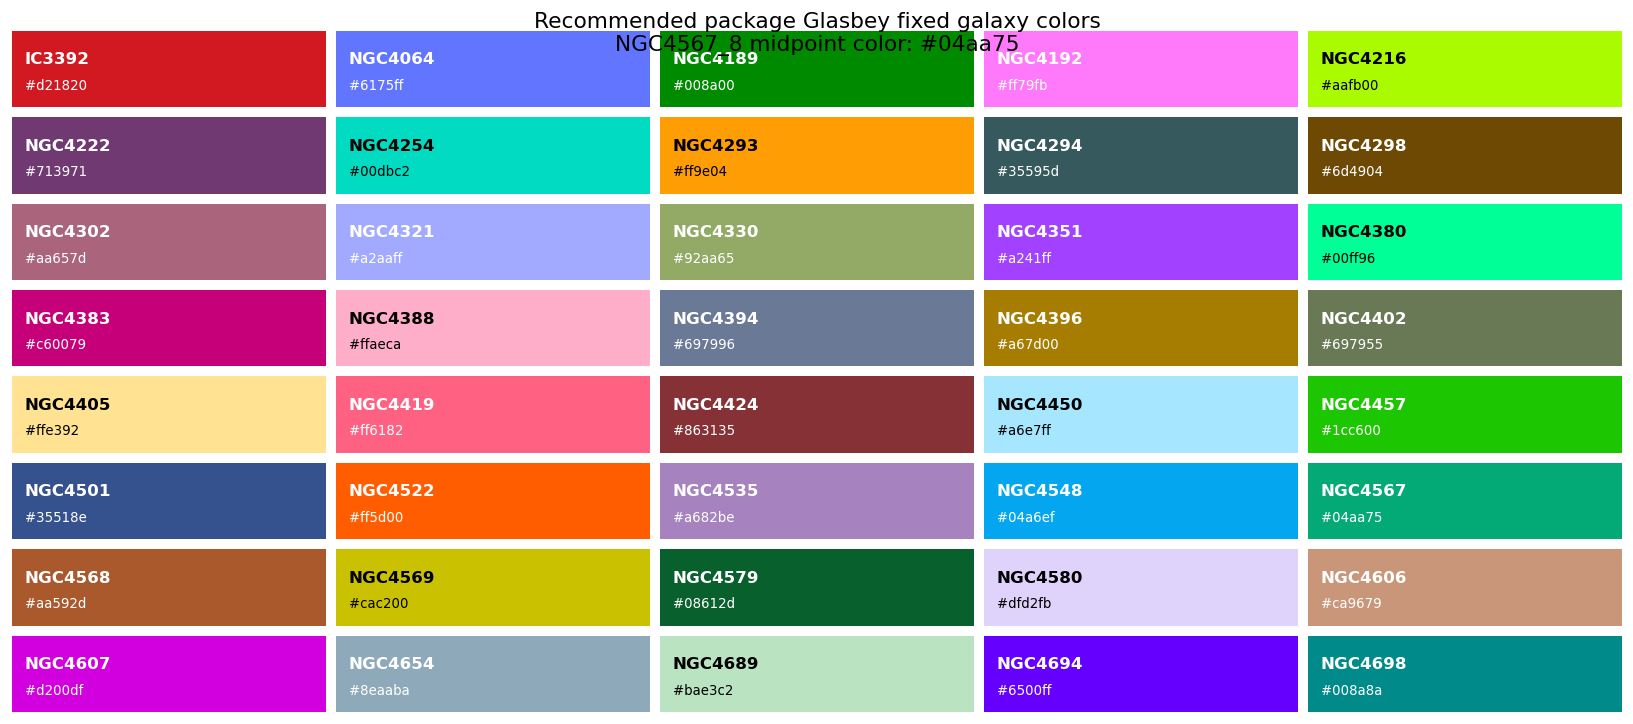

In [5]:
def text_color_for_rgb(rgb):
    return "black" if relative_luminance(np.asarray(rgb[:3])) > 0.45 else "white"


def plot_palette_swatches(palette, title, combined=None, ncols=5):
    n = len(palette)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 0.72 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.set_axis_off()

    for ax, row in zip(axes, palette.itertuples(index=False)):
        rgb = to_rgb(row.hex)
        ax.add_patch(Rectangle((0, 0), 1, 1, color=row.hex, transform=ax.transAxes))
        ax.text(
            0.04, 0.62, row.galaxy,
            transform=ax.transAxes,
            ha="left", va="center",
            color=text_color_for_rgb(rgb),
            fontweight="bold",
        )
        ax.text(
            0.04, 0.28, row.hex,
            transform=ax.transAxes,
            ha="left", va="center",
            color=text_color_for_rgb(rgb),
            fontsize=8,
        )

    subtitle = ""
    if combined is not None:
        subtitle = f"\n{combined['galaxy']} midpoint color: {combined['hex']}"
    fig.suptitle(f"{title}{subtitle}", y=1.02, fontsize=13)
    return fig

plot_palette_swatches(recommended, "Recommended package Glasbey fixed galaxy colors", combined=combined_color);

## Alternative 40-color candidates

The key distinction:

- **Package categorical palettes**: `glasbey.create_palette(40)`, `colorcet.glasbey[:40]`, and `distinctipy.get_colors(40)`.
- **Local categorical fallback**: local Glasbey-style 40, still useful if a different machine lacks the packages.
- **Matplotlib categorical baseline**: greedy 40 selected from `tab20`, `tab20b`, and `tab20c`.
- **Sampled continuous palettes**: `turbo`, `nipy_spectral`, `gist_rainbow`, and `hsv`; these are shown only as comparisons.

Distances below are approximate CIELAB distances. Larger is better. `min_pairwise_dist` reveals whether any two colors in the whole 40-color set are very similar. `min_black_rgb_dist` checks the reserved-black constraint.

In [6]:
def palette_metrics(palette):
    rgb = np.array([to_rgb(hex_color) for hex_color in palette["hex"]])
    lab = rgb_to_lab(rgb)
    d = np.sqrt(np.sum((lab[:, None, :] - lab[None, :, :]) ** 2, axis=-1))
    d[d == 0] = np.nan
    nearest = np.nanmin(d, axis=1)
    adjacent = np.sqrt(np.sum((lab[1:] - lab[:-1]) ** 2, axis=1))
    pair_rows = palette["galaxy"].isin(PAIR_IDS).to_numpy()
    pair_distance = np.nan
    if pair_rows.sum() == 2:
        pair_lab = lab[pair_rows]
        pair_distance = float(np.sqrt(np.sum((pair_lab[0] - pair_lab[1]) ** 2)))

    nearest_partner = []
    galaxies = palette["galaxy"].tolist()
    for i, galaxy in enumerate(galaxies):
        j = int(np.nanargmin(d[i]))
        nearest_partner.append({
            "galaxy": galaxy,
            "nearest_galaxy": galaxies[j],
            "nearest_dist": float(d[i, j]),
        })

    return {
        "min_pairwise_dist": float(np.nanmin(d)),
        "median_nearest_dist": float(np.nanmedian(nearest)),
        "min_adjacent_order_dist": float(np.nanmin(adjacent)),
        "median_adjacent_order_dist": float(np.nanmedian(adjacent)),
        "NGC4567_to_NGC4568_dist": pair_distance,
        "min_black_rgb_dist": float(black_distance(rgb).min()),
    }, pd.DataFrame(nearest_partner).sort_values("nearest_dist")


def continuous_sample_palette(cmap_name, interleave=False):
    if cmap_name == "hsv":
        positions = np.linspace(0.0, 1.0, len(sample_df), endpoint=False)
    else:
        positions = np.linspace(0.04, 0.96, len(sample_df))
    colors = plt.get_cmap(cmap_name)(positions)[:, :3]
    if interleave:
        step = 17
        order = [(i * step) % len(sample_df) for i in range(len(sample_df))]
        colors = colors[order]
    # Continuous comparison palettes may come close to black, but do not use them as the final convention.
    return build_palette_table(sample_df, cmap_name, colors)


def matplotlib_tab_combo_palette():
    colors = []
    for name in ["tab20", "tab20b", "tab20c"]:
        colors.extend(plt.get_cmap(name).colors)
    candidate_rgb = np.array(colors)[:, :3]
    candidate_lab = rgb_to_lab(candidate_rgb)
    selected = [0]
    while len(selected) < len(sample_df):
        d = np.sqrt(((candidate_lab[:, None, :] - candidate_lab[selected][None, :, :]) ** 2).sum(axis=2)).min(axis=1)
        d[selected] = -np.inf
        selected.append(int(np.argmax(d)))
    return build_palette_table(sample_df, "matplotlib_tab20_tab20b_tab20c_greedy40", candidate_rgb[selected])

candidate_palettes = [
    ("glasbey package create_palette 40", recommended),
    ("colorcet.glasbey first 40", build_palette_table(sample_df, "colorcet_glasbey_40", colorcet_glasbey_palette())),
    ("distinctipy exclude black/white 40", build_palette_table(sample_df, "distinctipy_exclude_black_white_40", distinctipy_palette())),
    ("local no-black Glasbey-style fallback 40", build_palette_table(sample_df, "local_no_black_glasbey_40", local_glasbey_palette())),
    ("Matplotlib tab20/tab20b/tab20c greedy 40", matplotlib_tab_combo_palette()),
    ("hsv sampled 40", continuous_sample_palette("hsv")),
    ("turbo sampled interleaved 40", continuous_sample_palette("turbo", interleave=True)),
    ("nipy_spectral sampled interleaved 40", continuous_sample_palette("nipy_spectral", interleave=True)),
    ("gist_rainbow sampled interleaved 40", continuous_sample_palette("gist_rainbow", interleave=True)),
]

metric_rows = []
nearest_tables = {}
for label, palette in candidate_palettes:
    metric, nearest = palette_metrics(palette)
    metric_rows.append({"palette": label, **metric})
    nearest_tables[label] = nearest

metrics_df = pd.DataFrame(metric_rows)
for col in metrics_df.columns:
    if col != "palette":
        metrics_df[col] = metrics_df[col].round(3 if col == "min_black_rgb_dist" else 1)

display(metrics_df)

print("Closest pairs for the recommended package Glasbey palette:")
display(nearest_tables["glasbey package create_palette 40"].head(12).assign(nearest_dist=lambda d: d["nearest_dist"].round(1)))

,palette,min_pairwise_dist,median_nearest_dist,min_adjacent_order_dist,median_adjacent_order_dist,NGC4567_to_NGC4568_dist,min_black_rgb_dist
0,glasbey package create_palette 40,19.9,27.0,32.7,84.6,83.8,0.421
1,colorcet.glasbey first 40,21.0,27.6,23.2,75.0,107.2,0.220
2,distinctipy exclude black/white 40,13.4,25.2,58.7,113.2,63.8,0.286
3,local no-black Glasbey-style fallback 40,27.1,29.0,38.5,84.6,55.6,0.583
4,Matplotlib tab20/tab20b/tab20c greedy 40,14.3,17.0,24.1,72.7,87.8,0.573
5,hsv sampled 40,1.4,13.7,1.4,16.9,8.0,1.000
6,turbo sampled interleaved 40,4.3,8.9,102.7,131.6,113.7,0.583
7,nipy_spectral sampled interleaved 40,3.1,9.5,102.6,147.7,107.9,0.556
8,gist_rainbow sampled interleaved 40,1.5,11.1,109.8,199.5,249.0,1.000


Closest pairs for the recommended package Glasbey palette:


,galaxy,nearest_galaxy,nearest_dist
36,NGC4654,NGC4394,19.9
17,NGC4394,NGC4654,19.9
27,NGC4535,NGC4321,22.4
11,NGC4321,NGC4535,22.4
8,NGC4294,NGC4394,22.9
23,NGC4450,NGC4654,22.9
30,NGC4568,NGC4298,23.8
9,NGC4298,NGC4568,23.8
35,NGC4607,NGC4351,24.1
13,NGC4351,NGC4607,24.1


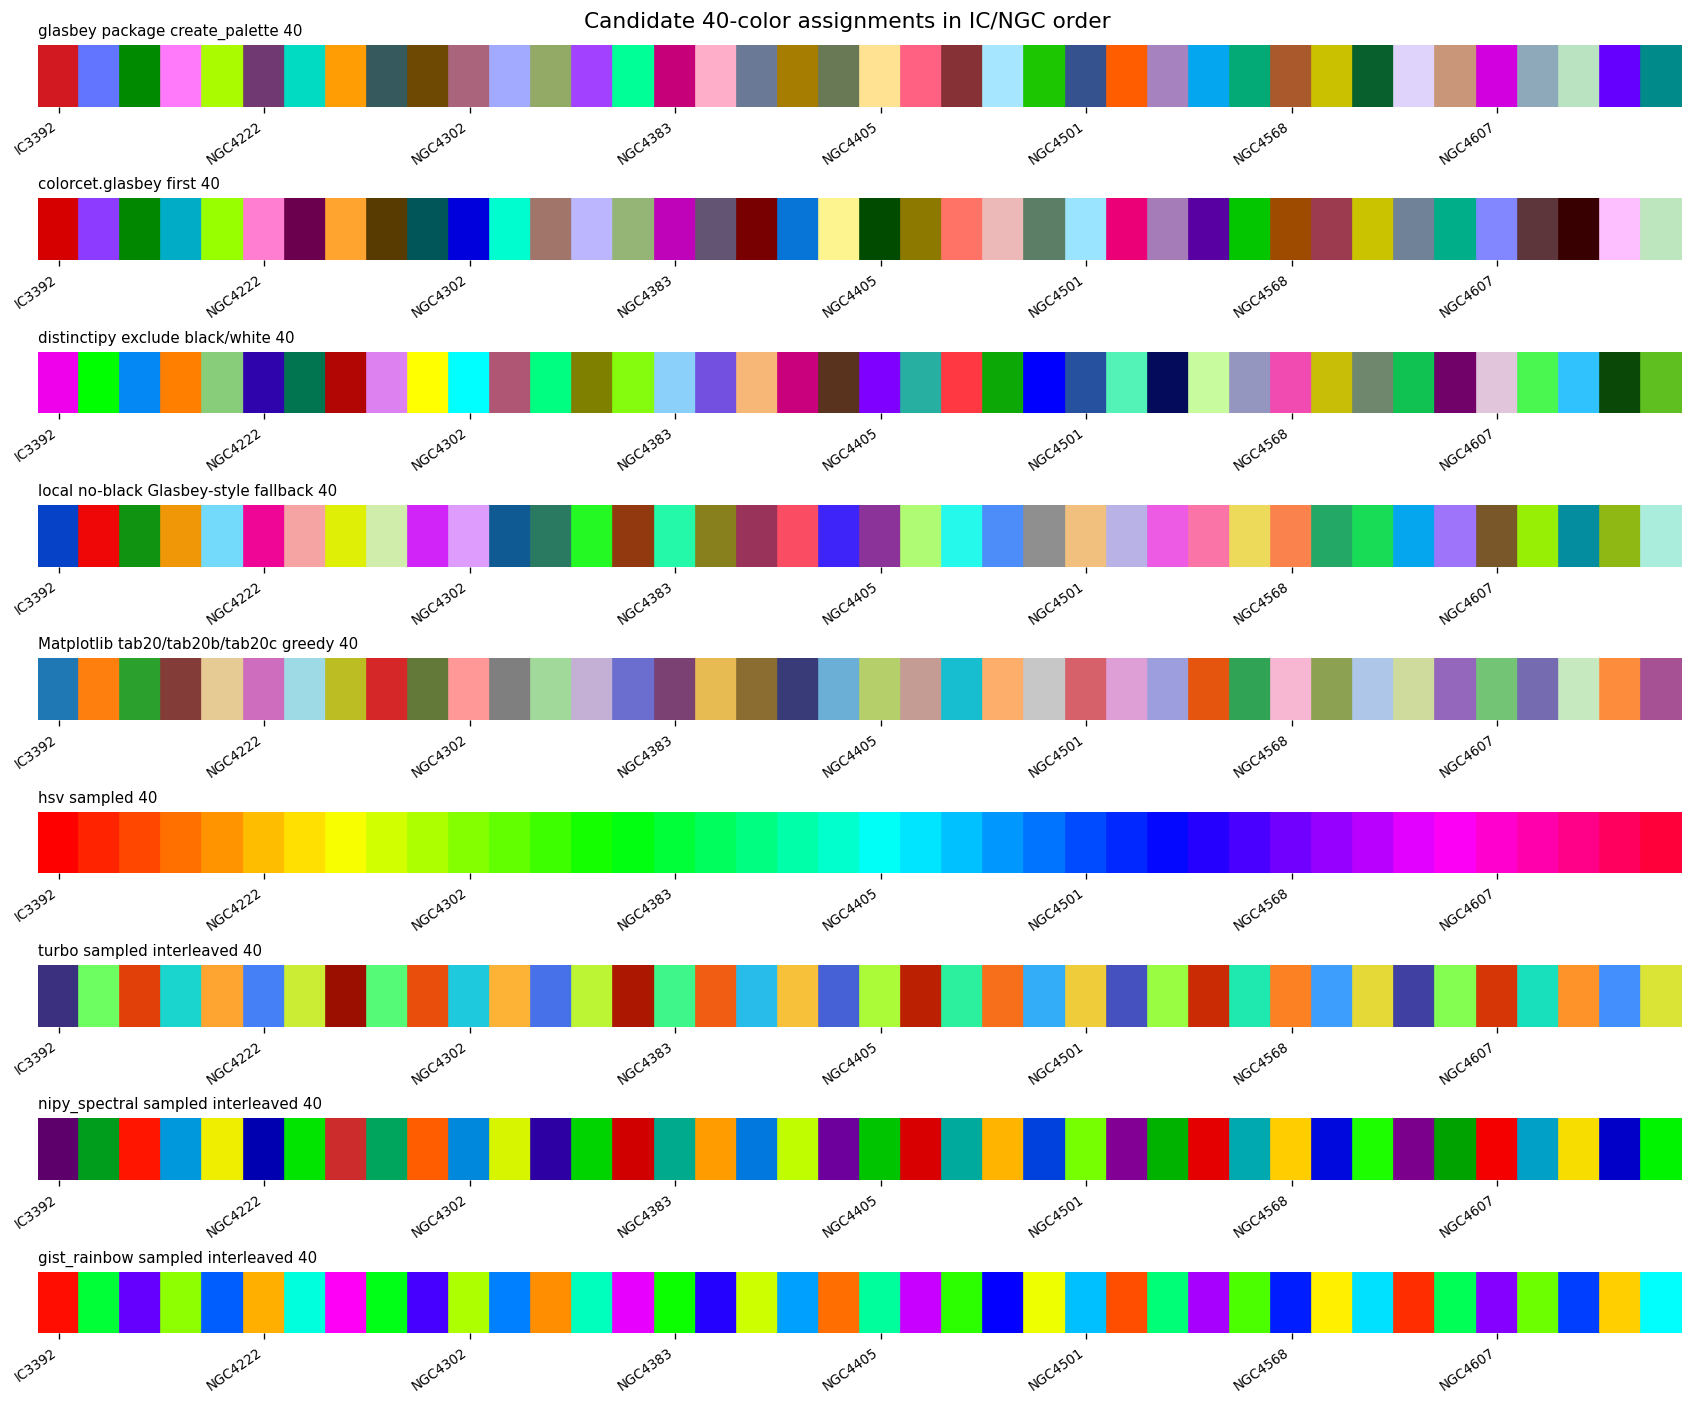

In [7]:
def plot_palette_bar(ax, palette, title):
    for i, row in enumerate(palette.itertuples(index=False)):
        ax.add_patch(Rectangle((i, 0), 1, 1, color=row.hex))
    ax.set_xlim(0, len(palette))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks(np.arange(0.5, len(palette), 5))
    ax.set_xticklabels(palette["galaxy"].iloc[::5], rotation=35, ha="right", fontsize=8)
    ax.set_title(title, loc="left", fontsize=9)
    ax.spines[:].set_visible(False)

fig, axes = plt.subplots(len(candidate_palettes), 1, figsize=(14, 11.5), constrained_layout=True)
for ax, (label, palette) in zip(axes, candidate_palettes):
    plot_palette_bar(ax, palette, label)
fig.suptitle("Candidate 40-color assignments in IC/NGC order", y=1.005, fontsize=13);

## Mock plot tests

These are arbitrary data, but they mimic two common cases:

1. many galaxy-colored points in one figure;
2. many galaxy-colored trend lines and markers;
3. the special `NGC4567`, `NGC4568`, and combined `NGC4567_8` fallback case.

The goal is only visual readability, not science interpretation.

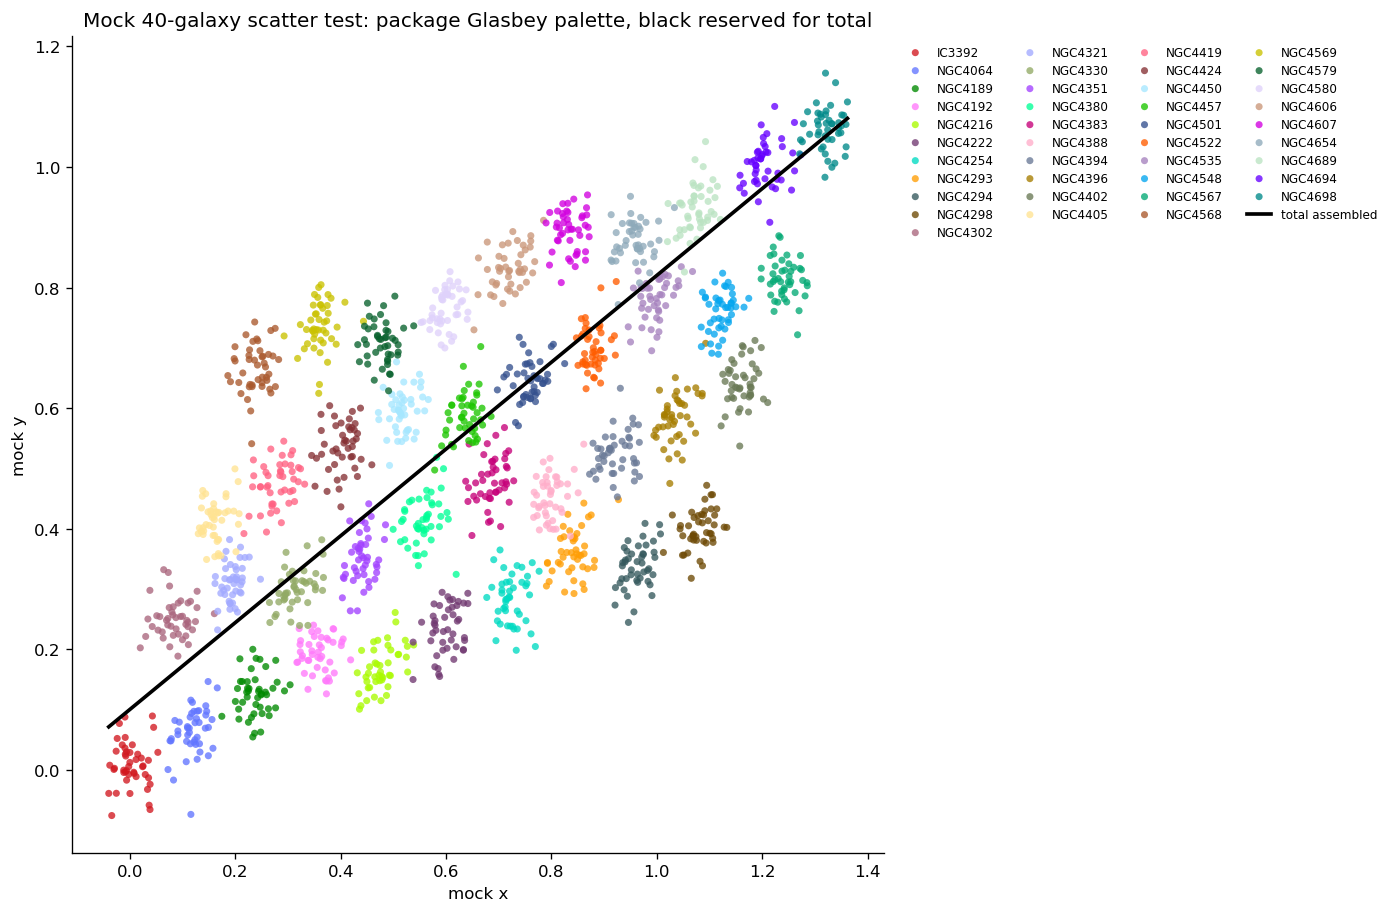

In [8]:
rng = np.random.default_rng(20260530)
color_map = dict(zip(recommended["galaxy"], recommended["hex"]))
color_map[COMBINED_ID] = combined_color["hex"]
TOTAL_ASSEMBLED_COLOR = "black"

mock_rows = []
for i, row in recommended.iterrows():
    n = 45
    x_center = 0.12 * (i % 10) + 0.08 * (i // 10)
    y_center = 0.18 * (i // 10) + 0.02 * (i % 4)
    x = x_center + rng.normal(0, 0.025, n)
    y = y_center + 0.35 * x + rng.normal(0, 0.035, n)
    mock_rows.append(pd.DataFrame({"galaxy": row["galaxy"], "x": x, "y": y}))
mock_df = pd.concat(mock_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(11.5, 7.5), constrained_layout=True)
for galaxy, group in mock_df.groupby("galaxy", sort=False):
    ax.scatter(
        group["x"], group["y"],
        s=18, alpha=0.78,
        color=color_map[galaxy],
        edgecolors="none",
        label=galaxy,
    )
ax.plot(
    np.linspace(mock_df["x"].min(), mock_df["x"].max(), 100),
    0.10 + 0.72 * np.linspace(mock_df["x"].min(), mock_df["x"].max(), 100),
    color=TOTAL_ASSEMBLED_COLOR,
    lw=2.2,
    label="total assembled",
)
ax.set_xlabel("mock x")
ax.set_ylabel("mock y")
ax.set_title("Mock 40-galaxy scatter test: package Glasbey palette, black reserved for total")
ax.legend(ncol=4, fontsize=7.2, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left");

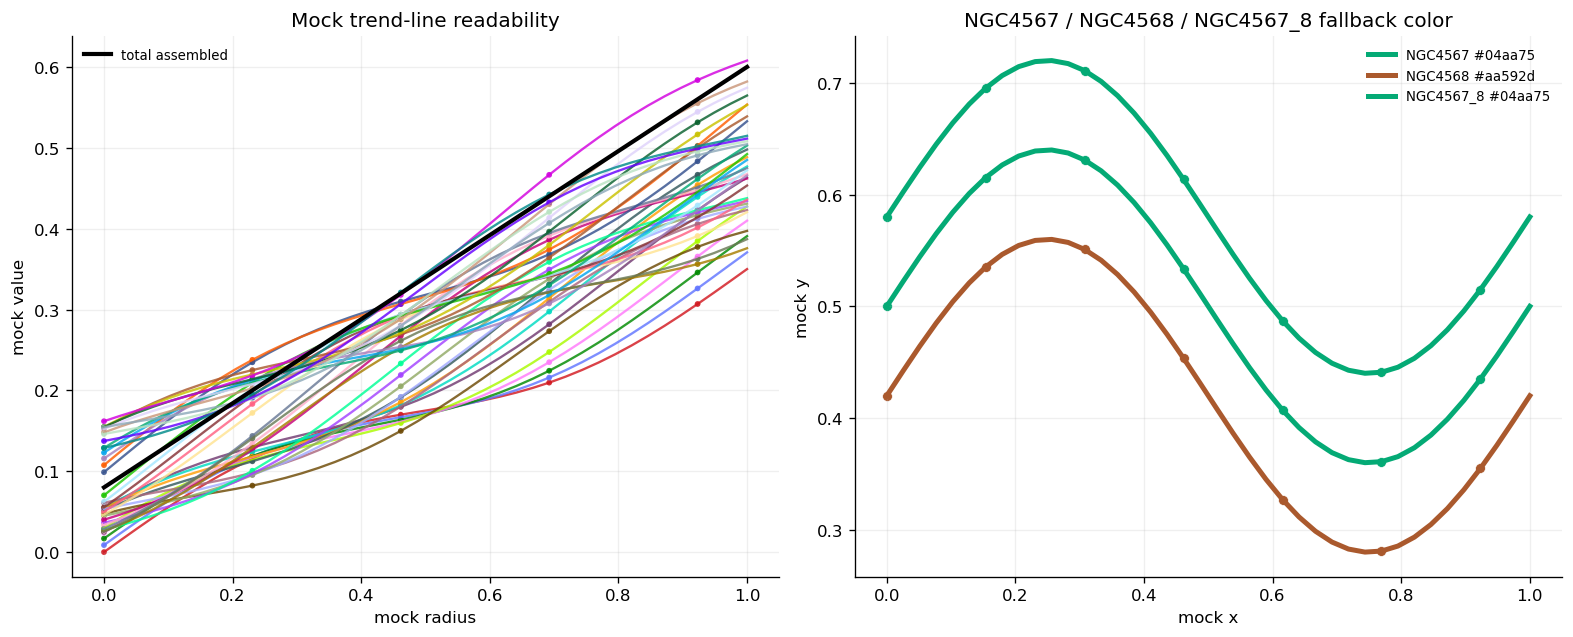

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
line_x = np.linspace(0, 1, 40)

for i, row in recommended.iterrows():
    galaxy = row["galaxy"]
    phase = 0.25 * i
    slope = 0.35 + 0.012 * (i % 9)
    offset = 0.02 * (i // 5)
    line_y = offset + slope * line_x + 0.035 * np.sin(2 * np.pi * line_x + phase)
    axes[0].plot(line_x, line_y, color=color_map[galaxy], lw=1.4, alpha=0.82)
    axes[0].scatter(line_x[::9], line_y[::9], color=color_map[galaxy], s=12, edgecolors="none", alpha=0.9)
axes[0].plot(line_x, 0.08 + 0.52 * line_x, color=TOTAL_ASSEMBLED_COLOR, lw=2.5, label="total assembled")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title("Mock trend-line readability")
axes[0].set_xlabel("mock radius")
axes[0].set_ylabel("mock value")

for galaxy in [PAIR_IDS[0], PAIR_IDS[1], COMBINED_ID]:
    c = color_map[galaxy]
    y = 0.5 + (0.08 if galaxy == PAIR_IDS[0] else -0.08 if galaxy == PAIR_IDS[1] else 0.0) + 0.14 * np.sin(2 * np.pi * line_x)
    axes[1].plot(line_x, y, color=c, lw=3, label=f"{galaxy} {c}")
    axes[1].scatter(line_x[::6], y[::6], color=c, s=35, edgecolors="white", linewidths=0.4)
axes[1].set_title("NGC4567 / NGC4568 / NGC4567_8 fallback color")
axes[1].set_xlabel("mock x")
axes[1].set_ylabel("mock y")
axes[1].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.2);

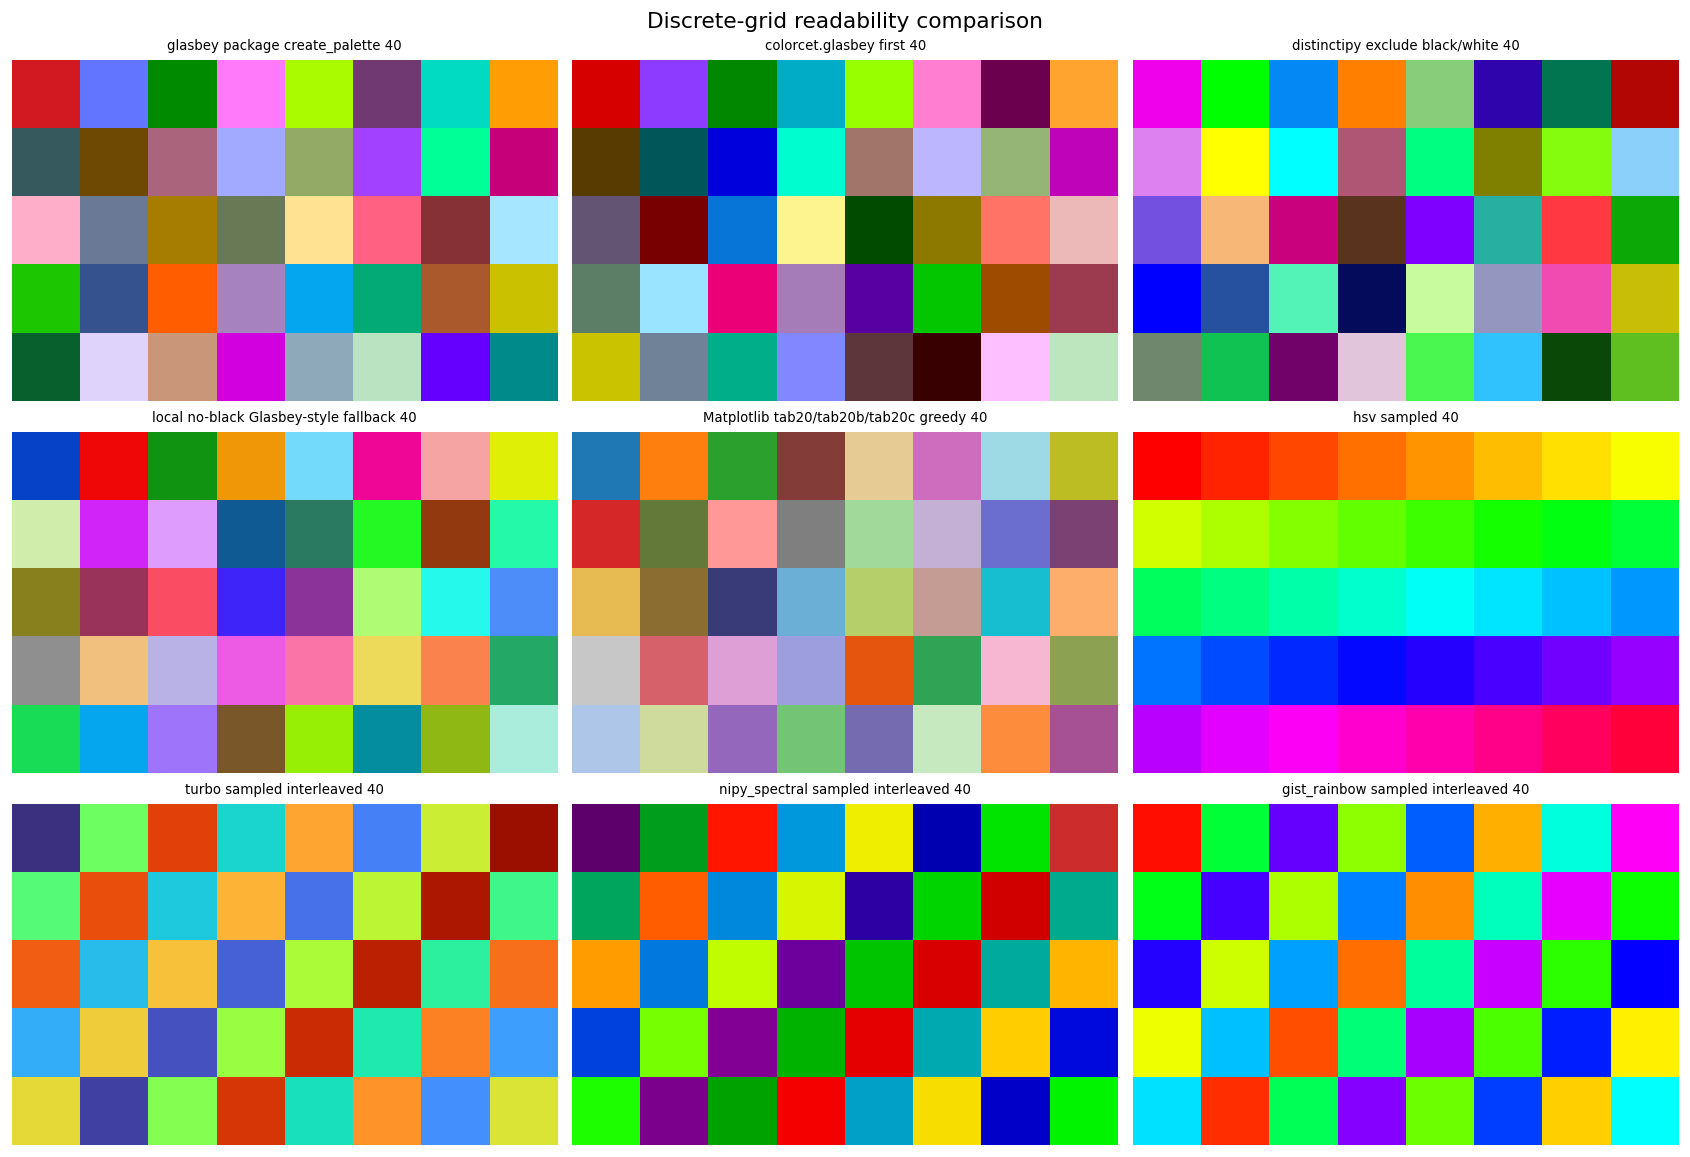

In [10]:
n = len(candidate_palettes)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.1 * nrows), constrained_layout=True)
axes = axes.ravel()
for ax in axes:
    ax.set_axis_off()
for ax, (label, palette) in zip(axes, candidate_palettes):
    cmap = ListedColormap(palette["hex"].tolist(), name=label.replace(" ", "_"))
    grid = np.arange(len(palette)).reshape(5, 8)
    ax.imshow(grid, cmap=cmap, vmin=-0.5, vmax=len(palette) - 0.5)
    ax.set_title(label, fontsize=8)
fig.suptitle("Discrete-grid readability comparison", y=1.02, fontsize=13);

## Copy-ready convention block

If this recommendation is accepted, the next step is to put this exact block in a small helper cell/module and replace old `plt.cm.tab20(np.linspace(...))` calls in notebooks from 2026-05-25 onward.

In [11]:
fixed_color_dict = {row.galaxy: row.hex for row in recommended.itertuples(index=False)}
fixed_color_dict[COMBINED_ID] = combined_color["hex"]

print("FIXED_GALAXY_ORDER = [")
for galaxy in recommended["galaxy"]:
    print(f"    {galaxy!r},")
print("]\n")

print(f"FIXED_GALAXY_PALETTE_NAME = {RECOMMENDED_PALETTE_NAME!r}")
print(f"TOTAL_ASSEMBLED_COLOR = {TOTAL_ASSEMBLED_COLOR!r}")
print("FIXED_GALAXY_COLORS = {")
for galaxy in list(recommended["galaxy"]) + [COMBINED_ID]:
    print(f"    {galaxy!r}: {fixed_color_dict[galaxy]!r},")
print("}\n")

print("from matplotlib.colors import ListedColormap")
print("FIXED_GALAXY_CMAP = ListedColormap([FIXED_GALAXY_COLORS[g] for g in FIXED_GALAXY_ORDER], name=FIXED_GALAXY_PALETTE_NAME)")

FIXED_GALAXY_ORDER = [
    'IC3392',
    'NGC4064',
    'NGC4189',
    'NGC4192',
    'NGC4216',
    'NGC4222',
    'NGC4254',
    'NGC4293',
    'NGC4294',
    'NGC4298',
    'NGC4302',
    'NGC4321',
    'NGC4330',
    'NGC4351',
    'NGC4380',
    'NGC4383',
    'NGC4388',
    'NGC4394',
    'NGC4396',
    'NGC4402',
    'NGC4405',
    'NGC4419',
    'NGC4424',
    'NGC4450',
    'NGC4457',
    'NGC4501',
    'NGC4522',
    'NGC4535',
    'NGC4548',
    'NGC4567',
    'NGC4568',
    'NGC4569',
    'NGC4579',
    'NGC4580',
    'NGC4606',
    'NGC4607',
    'NGC4654',
    'NGC4689',
    'NGC4694',
    'NGC4698',
]

FIXED_GALAXY_PALETTE_NAME = 'MAUVE_GALAXY_GLASBEY_PACKAGE_40'
TOTAL_ASSEMBLED_COLOR = 'black'
FIXED_GALAXY_COLORS = {
    'IC3392': '#d21820',
    'NGC4064': '#6175ff',
    'NGC4189': '#008a00',
    'NGC4192': '#ff79fb',
    'NGC4216': '#aafb00',
    'NGC4222': '#713971',
    'NGC4254': '#00dbc2',
    'NGC4293': '#ff9e04',
    'NGC4294': '#35595d',
    'NGC4298': '#6d4904'

## Current replacement targets found in post-2026-05-25 notebooks

A quick search found current explicit `tab20` galaxy-color calls in:

- `20260525_initial_further_check.ipynb`
- `20260529_initial_further_check_fake.ipynb`

Other post-0525 notebooks use physical scalar colormaps such as `viridis`, `magma`, `plasma`, `coolwarm`, or discrete validity maps; those are not galaxy-ID categorical colors and should not be replaced by this convention.